In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Configuración estética profesional para las visualizaciones
sns.set_theme(style="whitegrid")

# 1. Carga del dataset procesado
# Utilizamos parse_dates para que Pandas interprete la columna temporal correctamente
df = pd.read_csv('../data/processed/streaming_users_clean.csv', parse_dates=['last_login_date'])

# 2. Verificación de la importación
print("Estructura del Dataset:")
df.info()

# 3. Inspección visual de los primeros registros
display(df.head())

Estructura del Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   8000 non-null   int64         
 1   age                       8000 non-null   int64         
 2   subscription_plan         8000 non-null   str           
 3   monthly_watch_time_mins   8000 non-null   float64       
 4   country                   8000 non-null   str           
 5   favorite_genre            8000 non-null   str           
 6   last_login_date           8000 non-null   datetime64[us]
 7   customer_support_tickets  8000 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(3)
memory usage: 669.4 KB


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,0.0
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2.0
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0.0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0.0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1.0


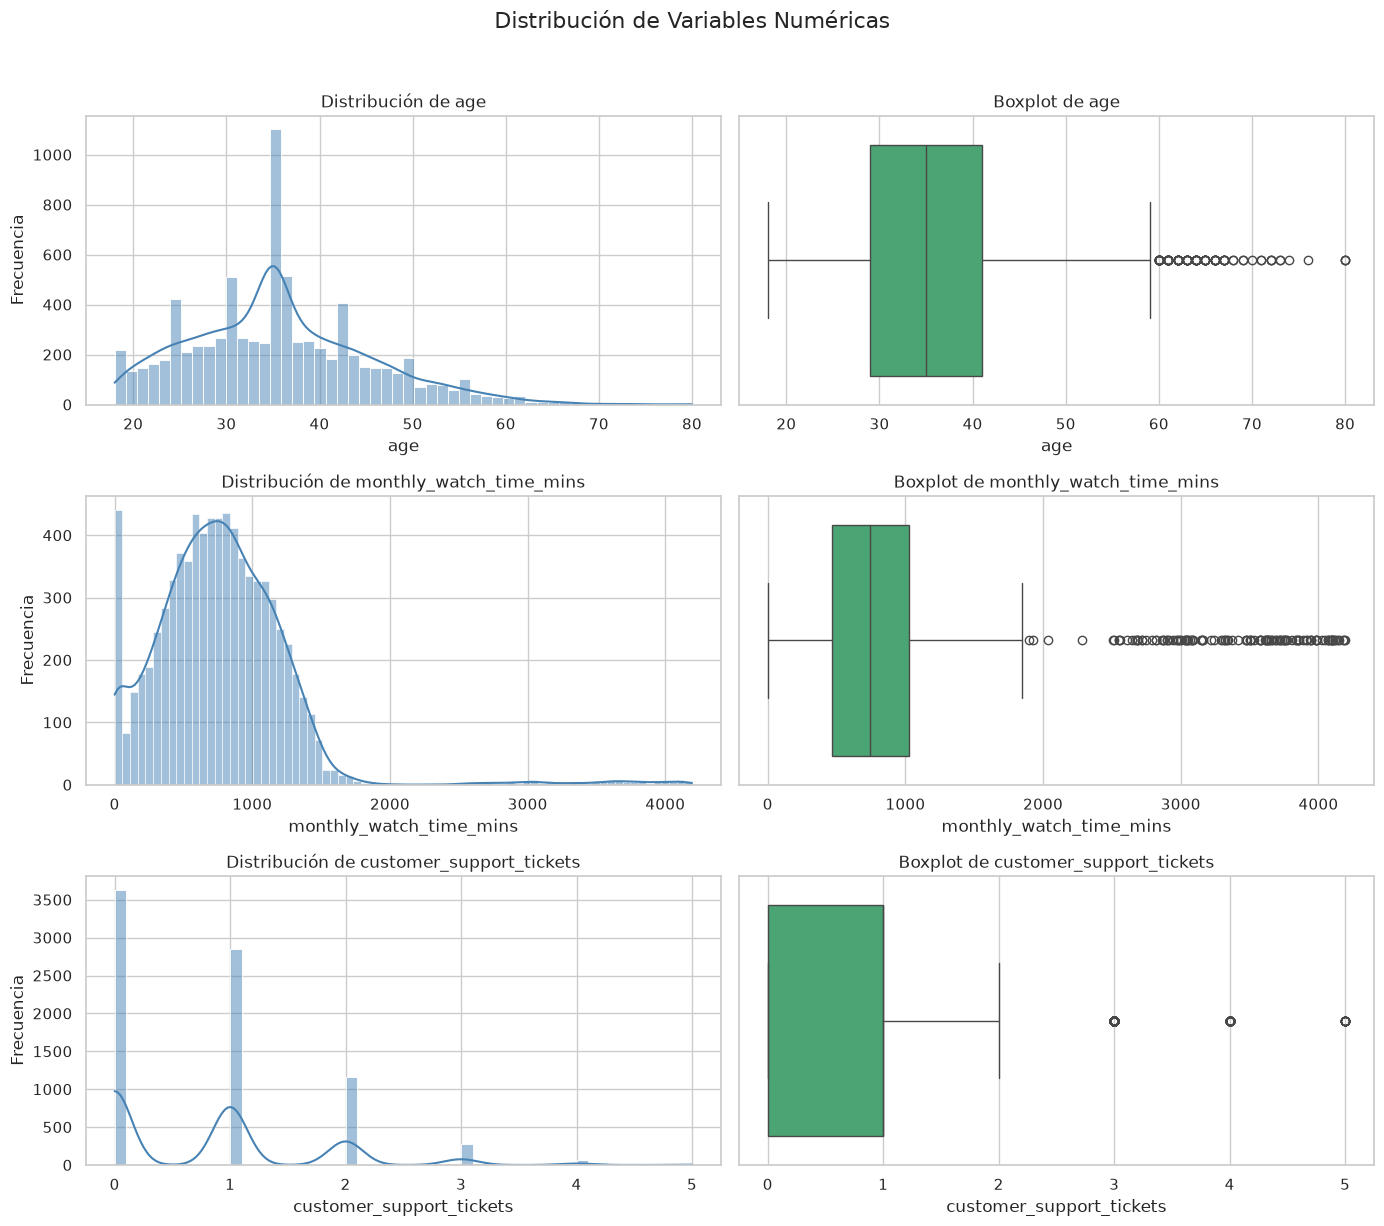

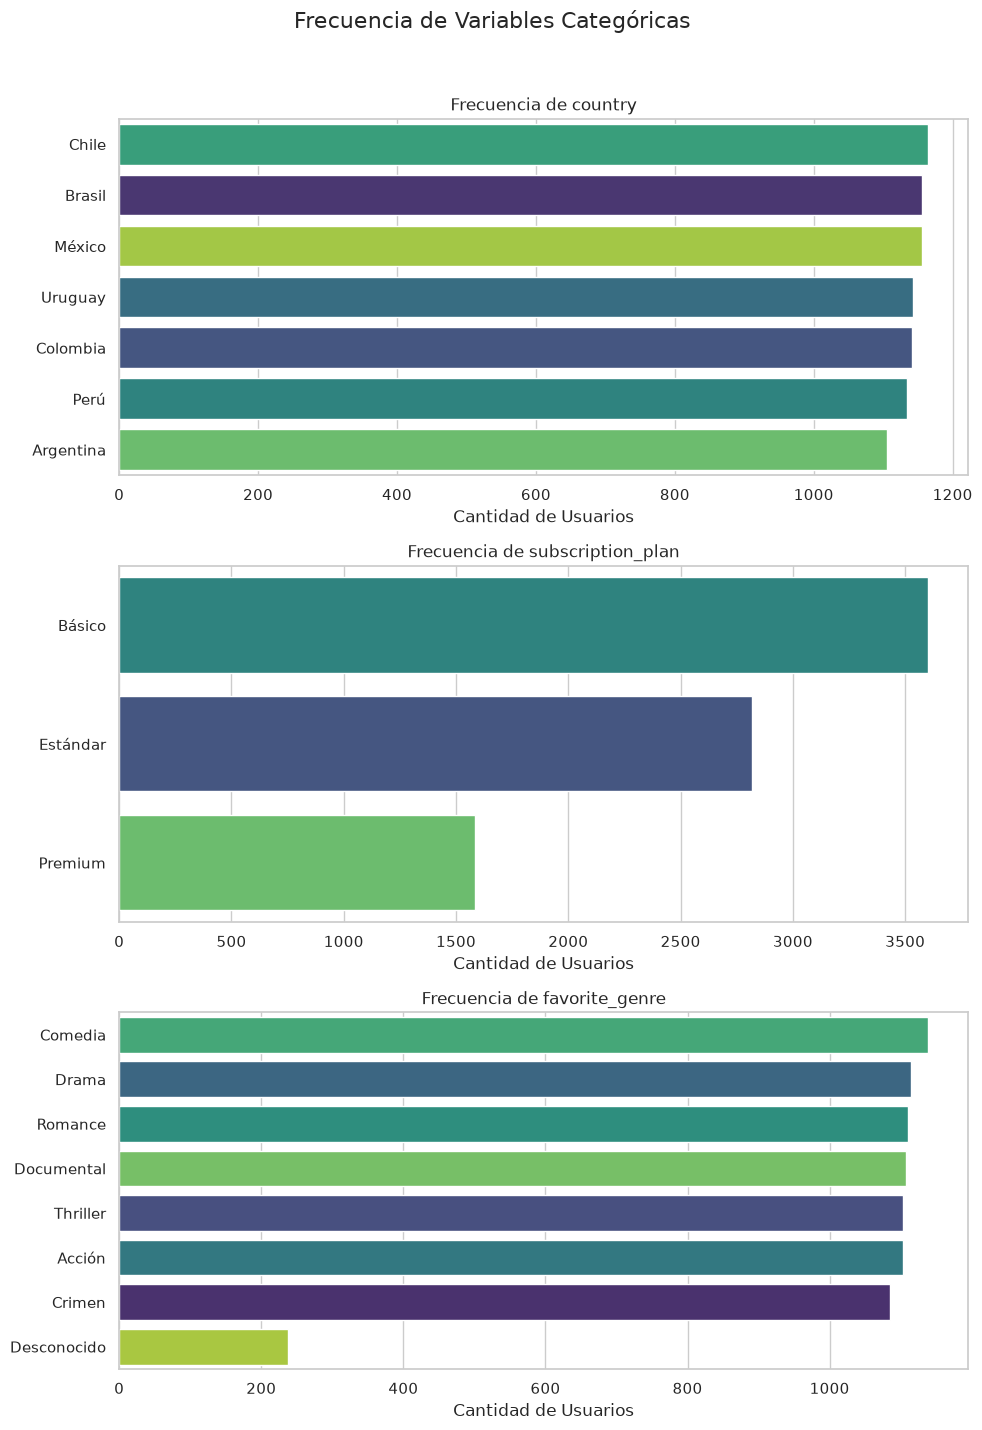

In [4]:
# 1. ANÁLISIS UNIVARIADO: VARIABLES NUMÉRICAS
columnas_numericas = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']

# Creamos una figura con 3 filas y 2 columnas
fig, axes = plt.subplots(nrows=len(columnas_numericas), ncols=2, figsize=(14, 12))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16, y=1.02)

for i, col in enumerate(columnas_numericas):
    # Histograma para ver la forma de la distribución
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Distribución de {col}')
    axes[i, 0].set_ylabel('Frecuencia')
    
    # Boxplot para evaluar la dispersión y confirmar la limpieza de outliers
    sns.boxplot(x=df[col], ax=axes[i, 1], color='mediumseagreen')
    axes[i, 1].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

# 2. ANÁLISIS UNIVARIADO: VARIABLES CATEGÓRICAS
columnas_categoricas = ['country', 'subscription_plan', 'favorite_genre']

# Creamos una figura con 3 filas y 1 columna
fig, axes = plt.subplots(nrows=len(columnas_categoricas), ncols=1, figsize=(10, 14))
fig.suptitle('Frecuencia de Variables Categóricas', fontsize=16, y=1.02)

for i, col in enumerate(columnas_categoricas):
    # Countplot ordenado de mayor a menor frecuencia
    sns.countplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        order=df[col].value_counts().index, 
        hue=col,
        legend=False,
        palette='viridis'
    )
    axes[i].set_title(f'Frecuencia de {col}')
    axes[i].set_xlabel('Cantidad de Usuarios')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

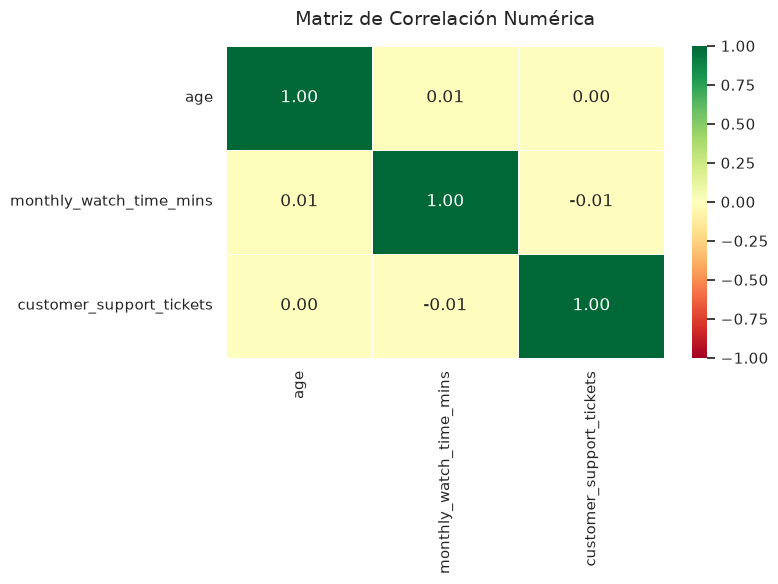

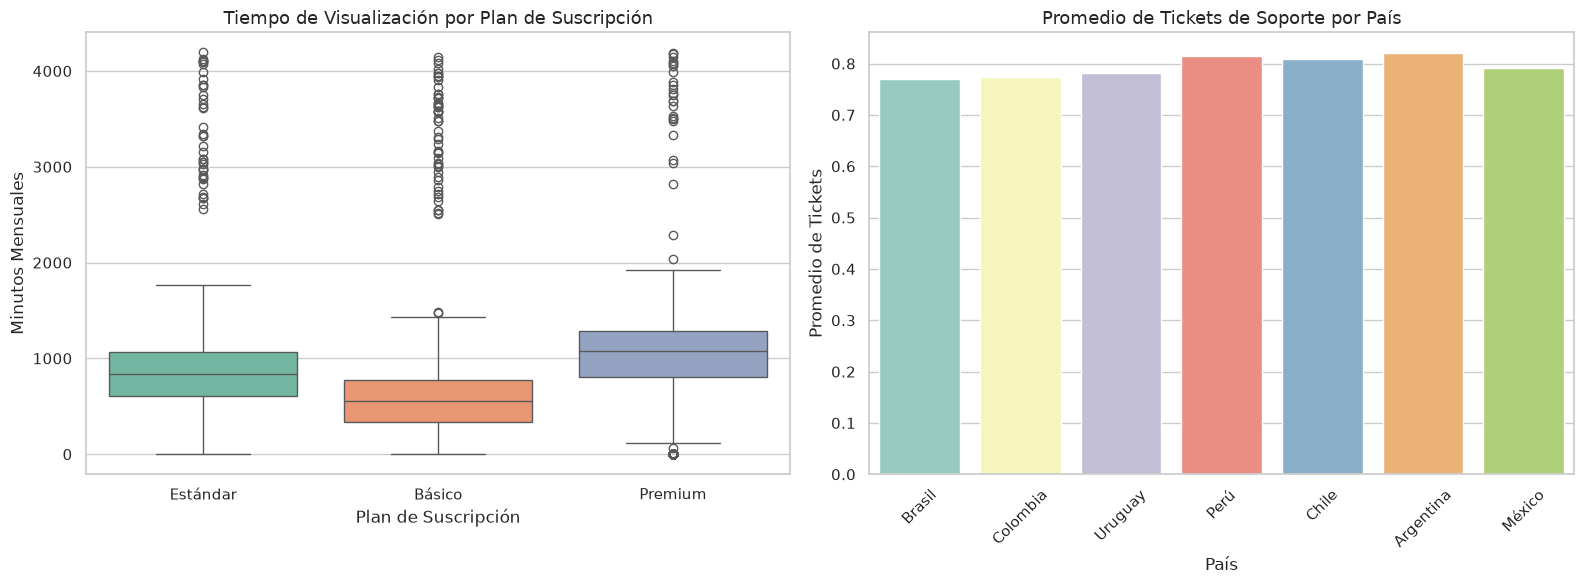

In [8]:
# 3. ANÁLISIS BIVARIADO: MATRIZ DE CORRELACIÓN
# Filtramos solo las columnas numéricas
columnas_num = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
matriz_correlacion = df[columnas_num].corr()

# Generación del Heatmap
plt.figure(figsize=(8, 6))
# Se reemplaza 'coolwarm' por 'RdYlGn' (Red, Yellow, Green) para un contraste tipo semáforo
sns.heatmap(matriz_correlacion, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación Numérica', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 4. ANÁLISIS BIVARIADO: CATEGÓRICO VS NUMÉRICO
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Boxplot: Distribución del tiempo de visualización según el plan de suscripción
# Corrección: Se añade hue='subscription_plan' y legend=False para evitar el FutureWarning
sns.boxplot(x='subscription_plan', y='monthly_watch_time_mins', data=df, ax=axes[0], hue='subscription_plan', palette='Set2', legend=False)
axes[0].set_title('Tiempo de Visualización por Plan de Suscripción', fontsize=13)
axes[0].set_xlabel('Plan de Suscripción')
axes[0].set_ylabel('Minutos Mensuales')

# Barplot: Promedio de tickets de soporte generados por país
# Corrección: Se añade hue='country' y legend=False para evitar el FutureWarning
sns.barplot(x='country', y='customer_support_tickets', data=df, ax=axes[1], hue='country', palette='Set3', errorbar=None, legend=False)
axes[1].set_title('Promedio de Tickets de Soporte por País', fontsize=13)
axes[1].set_xlabel('País')
axes[1].set_ylabel('Promedio de Tickets')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

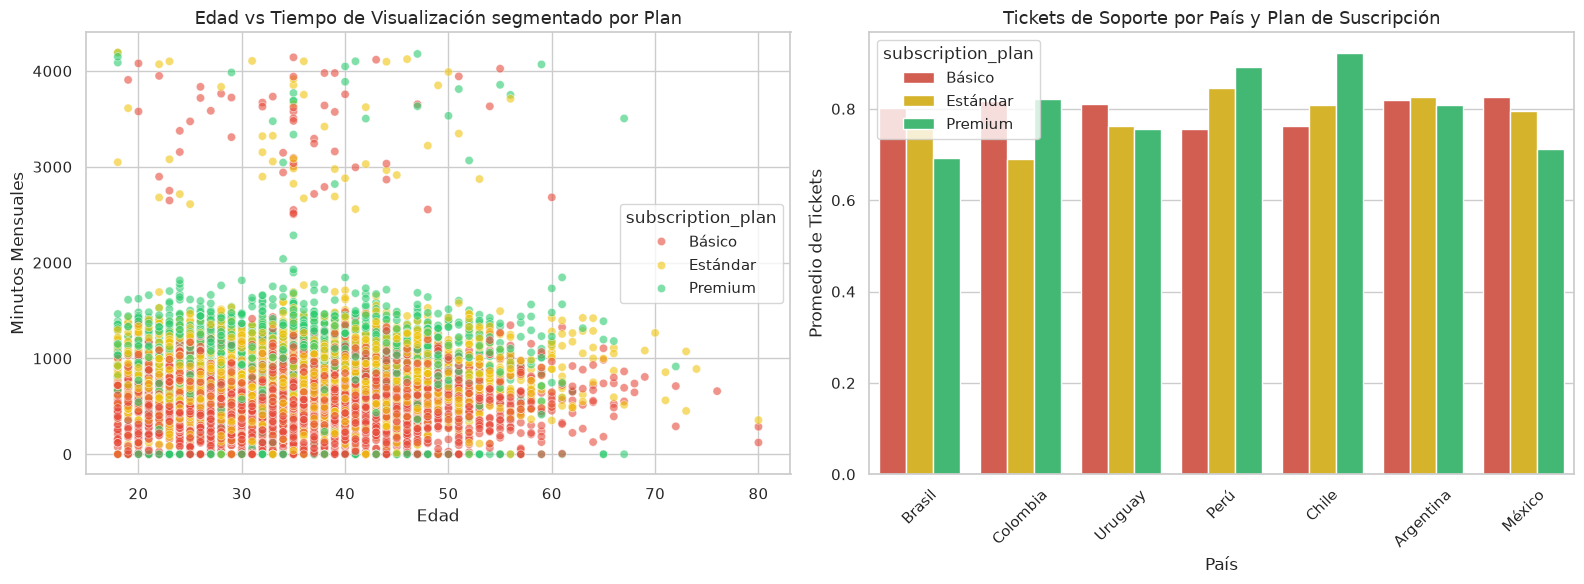

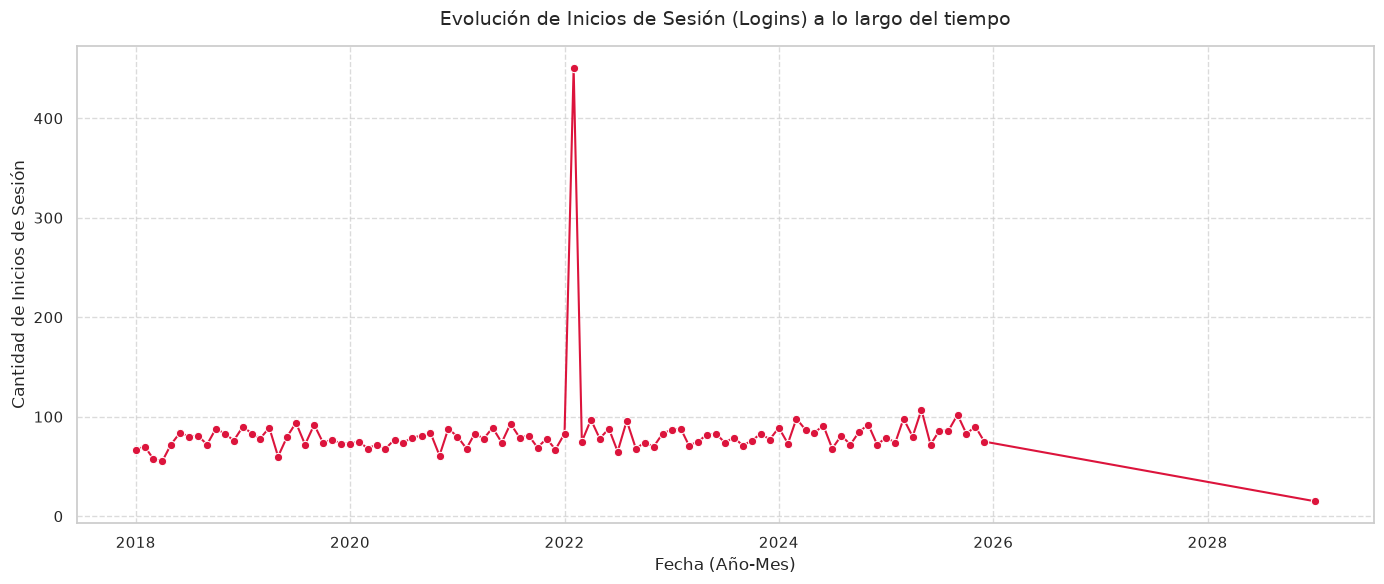

In [10]:
# 5. ANÁLISIS MULTIVARIADO
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Definimos el orden de los planes para consistencia
orden_planes = ['Básico', 'Estándar', 'Premium']
# Definimos los colores del semáforo: Rojo (Básico), Amarillo (Estándar), Verde (Premium)
colores_semaforo = ['#e74c3c', '#f1c40f', '#2ecc71']

# Scatterplot: Relación entre Edad y Tiempo de Visualización, segmentado por Plan
# Se aplica el orden y la paleta personalizada
sns.scatterplot(
    data=df, x='age', y='monthly_watch_time_mins', hue='subscription_plan', 
    hue_order=orden_planes, palette=colores_semaforo, alpha=0.6, ax=axes[0]
)
axes[0].set_title('Edad vs Tiempo de Visualización segmentado por Plan', fontsize=13)
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Minutos Mensuales')

# Barplot agrupado: Promedio de tickets por País, subdividido por Plan
sns.barplot(
    data=df, x='country', y='customer_support_tickets', hue='subscription_plan', 
    hue_order=orden_planes, palette=colores_semaforo, errorbar=None, ax=axes[1]
)
axes[1].set_title('Tickets de Soporte por País y Plan de Suscripción', fontsize=13)
axes[1].set_xlabel('País')
axes[1].set_ylabel('Promedio de Tickets')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 6. ANÁLISIS TEMPORAL (SERIES DE TIEMPO)
# Extraemos el periodo (Año-Mes) para agrupar la actividad temporal
df['login_month'] = df['last_login_date'].dt.to_period('M')

# Contabilizamos inicios de sesión por mes
logins_por_mes = df.groupby('login_month').size().reset_index(name='conteo')
# Reconvertimos a timestamp para la correcta renderización del gráfico
logins_por_mes['login_month'] = logins_por_mes['login_month'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
sns.lineplot(data=logins_por_mes, x='login_month', y='conteo', marker='o', color='crimson')
plt.title('Evolución de Inicios de Sesión (Logins) a lo largo del tiempo', fontsize=14, pad=15)
plt.xlabel('Fecha (Año-Mes)')
plt.ylabel('Cantidad de Inicios de Sesión')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Limpieza estructural: eliminamos la columna temporal auxiliar
df = df.drop(columns=['login_month'])